# Projet 2 — Contrôle Optimal d'une Épidémie (Vaccination Dynamique)

**Objectif :** Résoudre un problème de contrôle optimal continu (Hamiltonien de Pontryagin)  
pour minimiser simultanément le nombre d'infectés et le coût de la campagne de vaccination.

## Table des matières
1. [Imports & Paramètres](#1)
2. [Étape 1 — Formulation Hamiltonienne (Pontryagin)](#2)
3. [Étape 2 — Algorithme Forward-Backward Sweep](#3)
4. [Étape 3 — Politique optimale u*(t) pour c ∈ {10, 1, 0.1}](#4)
5. [Étape 4 — Comparaison : Optimal vs Vaccination constante](#5)
6. [Étape 5 — Contrainte d'état I(t) ≤ I_max (méthode de pénalité)](#6)
7. [Synthèse et interprétation](#7)


## 1. Imports & Paramètres <a id='1'></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown

# ── Paramètres épidémiologiques(modèle SIR) ────────────────────────────────────────────────
BETA  = 0.30    # taux de transmission β (contacts infectieux / jour)
GAMMA = 0.10    # taux de guérison    γ (1/jour)
UMAX  = 0.30    # taux maximal de vaccination u_max (fraction de S / jour)
T     = 200     # horizon temporel (jours)
N     = 4000    # nombre de pas de discrétisation
DT    = T / N   # pas de temps Δt
t_arr = np.linspace(0, T, N + 1)

# ── Conditions initiales (population normalisée à 1) ──────────────────────────
S0, I0, R0 = 0.97, 0.03, 0.00

R0_epi = BETA / GAMMA  # nombre de reproduction de base

PAL = {'c10':'#1A237E','c1':'#BF360C','c01':'#1B5E20','ref':'#546E7A','pen':'#C62828'} # dictionnaire de couleur(facile a gerer la suite)


## 2. Étape 1 — Formulation Hamiltonienne (Principe du Minimum de Pontryagin) <a id='2'></a>

### 2.1 Modèle SIR avec contrôle de vaccination

$$
\begin{cases}\dot{S} = -\beta S I - u(t), \quad S(0) = S_0 \\
\dot{I} = \beta S I - \gamma I, \quad I(0) = I_0 \\
\dot{R} = \gamma I + u(t), \quad R(0) = R_0
\end{cases}
$$

avec $u(t) \in [0, u_{\max}]$ le taux de vaccination journalier. Les vaccinés passent directement de $S$ à $R$.

### 2.2 Fonction coût

$$J = \int_0^T \left[ I(t) + \frac{c}{2}\, u(t)^2 \right] dt$$

Le terme $I(t)$ pénalise le nombre d'infectés, et $\frac{c}{2}u^2$ modélise le coût quadratique de la vaccination.

### 2.3 Hamiltonien

$$H(S, I, R, \lambda, u) = I + \frac{c}{2}u^2 + \lambda_S(-\beta SI - u) + \lambda_I(\beta SI - \gamma I) + \lambda_R(\gamma I + u)$$

### 2.4 Équations adjointes

$$
\begin{cases}
\dot{\lambda}_S = -\frac{\partial H}{\partial S} = \beta I(\lambda_S - \lambda_I), \quad \lambda_S(T) = 0 \\
\dot{\lambda}_I = -\frac{\partial H}{\partial I} = -1 + \beta S(\lambda_S - \lambda_I) + \gamma \lambda_I, \quad \lambda_I(T) = 0 \\
\dot{\lambda}_R = -\frac{\partial H}{\partial R} = 0 \implies \lambda_R(t) \equiv 0 \quad \forall t
\end{cases}
$$

### 2.5 Contrôle optimal (condition de stationnarité)

$$\frac{\partial H}{\partial u} = cu - \lambda_S = 0 \implies u^*(t) = \text{Proj}_{[0,u_{\max}]}\!\left(\frac{\lambda_S(t)}{c}\right)$$

$$u^*(t) = \begin{cases} u_{\max} & \text{si } \lambda_S \geq c\,u_{\max} \quad (\text{saturation / bang-bang})\\ \lambda_S/c & \text{si } 0 < \lambda_S < c\,u_{\max} \quad (\text{contrôle singulier})\\ 0 & \text{si } \lambda_S \leq 0 \quad (\text{inactivité}) \end{cases}$$

ie $$u^*(t) = \min\left(u_{\max}, \max\left(0, \frac{\lambda_S(t)}{c}\right)\right)$$

## 3. Étape 2 — Algorithme Forward-Backward Sweep <a id='3'></a>

In [2]:
# NUMÉRIQUES

def forward_pass(u, S, I, R):
    """Intégration forward des équations d'état (Euler explicite)."""
    S[0], I[0], R[0] = S0, I0, R0
    for k in range(N):
        # On s'assure que u ne vide pas S en un pas
        uk = np.clip(u[k], 0.0, min(UMAX, S[k] / DT))
        S[k+1] = np.clip(S[k] + DT * (-BETA * S[k] * I[k] - uk), 0.0, 1.0)
        I[k+1] = np.clip(I[k] + DT * ( BETA * S[k] * I[k] - GAMMA * I[k]), 0.0, 1.0)
        R[k+1] = np.clip(R[k] + DT * ( GAMMA * I[k] + uk), 0.0, 1.0)


def backward_pass(S, I, lambda_S, lambda_I, I_max=None, rho=0.0):
    """Intégration backward des équations adjointes (conditions terminales λ(T)=0)."""
    lambda_S[N] = lambda_I[N] = 0.0
    for k in range(N - 1, -1, -1):
        # Gradient du terme de pénalité de contrainte d'état
        pen = 2.0 * rho * max(0.0, I[k] - I_max) if I_max is not None else 0.0
        lambda_S[k] = lambda_S[k+1] - DT * (BETA * I[k] * (lambda_S[k+1] - lambda_I[k+1]))
        lambda_I[k] = lambda_I[k+1] - DT * (-(1.0 + pen) + BETA * S[k] * (lambda_S[k+1] - lambda_I[k+1]) + GAMMA * lambda_I[k+1])


def fb_sweep(c, I_max=None, rho=0.0, tol=1e-9, max_iter=6000, alpha=0.5):
    """
    Forward-Backward Sweep : itération sur la loi de contrôle.
    
    Parameters
    ----------
    c       : coût relatif de la vaccination (scalaire > 0)
    I_max   : contrainte d'état I(t) ≤ I_max (None = sans contrainte)
    rho     : coefficient de pénalité pour la contrainte
    tol     : tolérance de convergence sur ||u_new - u_old||_∞
    alpha   : paramètre de mise-à-jour convexe (0 < α ≤ 1)
    """
    S  = np.zeros(N+1); I  = np.zeros(N+1); R  = np.zeros(N+1)
    lambda_S = np.zeros(N+1); lambda_I = np.zeros(N+1)
    u  = np.full(N+1, UMAX * 0.05)   # initialisation u ≡ petit taux constant
    errs = []
    converged_at = max_iter

    for it in range(max_iter):
        u_prev = u.copy()
        # 1. Intégration forward
        forward_pass(u, S, I, R)
        # 2. Intégration backward des adjointes
        backward_pass(S, I, lambda_S, lambda_I, I_max=I_max, rho=rho)
        # 3. Mise-à-jour du contrôle via la condition de stationnarité
        u_new = np.clip(lambda_S / c, 0.0, UMAX)
        # 4. Mise-à-jour convexe (relaxation) pour la stabilité
        u = alpha * u_new + (1.0 - alpha) * u_prev # pour eviter une convergence lente
        err = np.max(np.abs(u - u_prev))
        errs.append(err)
        if err < tol and it > 30:      # juste pour forcer a travailler pendant au moins 30 iteration(ça rassure la convergence)
            converged_at = it + 1
            break

    J   = np.trapezoid(I + c * u**2 / 2.0, t_arr)
    J_I = np.trapezoid(I, t_arr)
    J_u = np.trapezoid(c * u**2 / 2.0, t_arr)

    return dict(t=t_arr, S=S, I=I, R=R, u=u,
                lambda_S=lambda_S, lambda_I=lambda_I,
                J=J, J_I=J_I, J_u=J_u,
                iters=converged_at, errs=np.array(errs))


def sir_libre():
    """Dynamique SIR sans contrôle (cas de référence)."""
    S=np.zeros(N+1);I=np.zeros(N+1);R=np.zeros(N+1)
    S[0],I[0],R[0]=S0,I0,R0
    for k in range(N):
        S[k+1]=S[k]+DT*(-BETA*S[k]*I[k])
        I[k+1]=I[k]+DT*(BETA*S[k]*I[k]-GAMMA*I[k])
        R[k+1]=R[k]+DT*(GAMMA*I[k])
    return dict(t=t_arr,S=S,I=I,R=R,J=np.trapezoid(I,t_arr))


def sir_constant(uc, c):
    """SIR avec vaccination à taux constant u(t) ≡ uc."""
    S=np.zeros(N+1);I=np.zeros(N+1);R=np.zeros(N+1)
    S[0],I[0],R[0]=S0,I0,R0
    for k in range(N):
        uk=np.clip(uc,0.,S[k]/DT)
        S[k+1]=np.clip(S[k]+DT*(-BETA*S[k]*I[k]-uk),0.0,1.0)
        I[k+1]=np.clip(I[k]+DT*(BETA*S[k]*I[k]-GAMMA*I[k]),0.0,1.0)
        R[k+1]=np.clip(R[k]+DT*(GAMMA*I[k]+uk),0.0,1.0)
    return dict(t=t_arr,S=S,I=I,R=R,J=np.trapezoid(I + c*uc**2/2.0,t_arr))



## 4. Étape 3 — Politique optimale u*(t) pour c ∈ {10, 1, 0.1} <a id='4'></a>

In [3]:
# ── Résolution pour 3 valeurs de c ──────────────────────────────────────────
c_vals   = [10.0, 1.0, 0.1]
col_keys = ['c10', 'c1', 'c01']
labels   = ['c = 10  (vaccination coûteuse)', 
            'c = 1   (coût moyen)',
            'c = 0.1 (vaccination bon marché)']

RES = {}
ref = sir_libre()

print(f"Référence SIR sans contrôle : J = {ref['J']:.4f}\n")
for c, ck in zip(c_vals, col_keys):
    r = fb_sweep(c)
    RES[c] = r
    reduction = 100*(1 - r['J']/ref['J'])
    print(f"  c={c:5.1f} | J={r['J']:.4f} | réduction={reduction:.1f}% | "      f"J_I={r['J_I']:.4f} | J_u={r['J_u']:.4f} | {r['iters']} itérations")


Référence SIR sans contrôle : J = 9.4287

  c= 10.0 | J=1.5930 | réduction=83.1% | J_I=0.6218 | J_u=0.9712 | 32 itérations
  c=  1.0 | J=1.3815 | réduction=85.3% | J_I=0.4585 | J_u=0.9230 | 32 itérations
  c=  0.1 | J=0.6546 | réduction=93.1% | J_I=0.4585 | J_u=0.1961 | 32 itérations


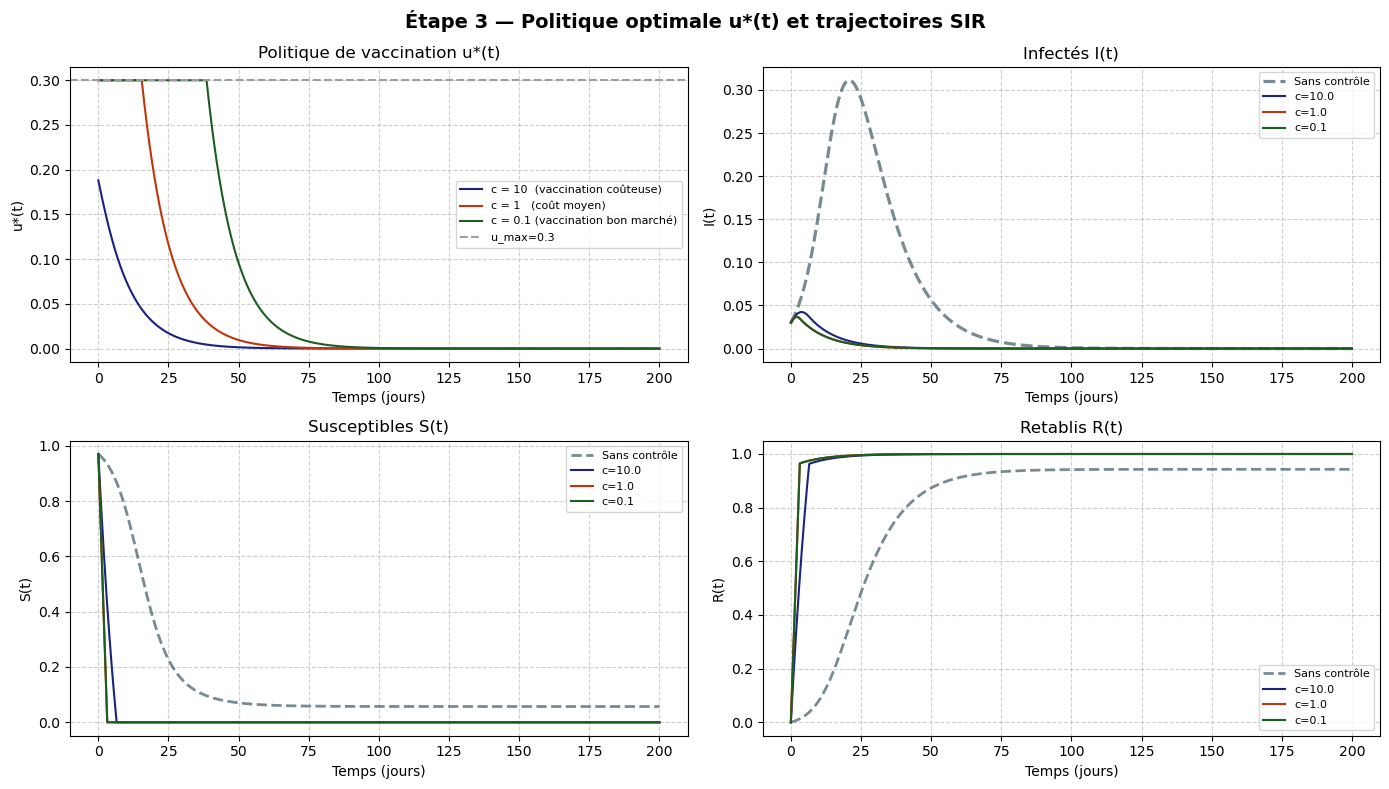

In [4]:
# ── Figure Étape 3 ──────────────────────────────────────────────────────────
plt.figure(figsize=(14, 8))
plt.suptitle("Étape 3 — Politique optimale u*(t) et trajectoires SIR", 
             fontsize=14, fontweight='bold')

# 1. Politique u*(t)
plt.subplot(2, 2, 1)
for c, ck, lab in zip(c_vals, col_keys, labels):
    plt.plot(t_arr, RES[c]['u'], color=PAL[ck], label=lab)
plt.axhline(UMAX, color='#9E9E9E', ls='--', lw=1.5, label=f'u_max={UMAX}')
plt.title('Politique de vaccination u*(t)')
plt.xlabel('Temps (jours)')
plt.ylabel('u*(t)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=8)

# 2. Infectés I(t)
plt.subplot(2, 2, 2)
plt.plot(t_arr, ref['I'], color=PAL['ref'], ls='--', lw=2.3, label='Sans contrôle', alpha=0.8)
for c, ck, lab in zip(c_vals, col_keys, labels):
    plt.plot(t_arr, RES[c]['I'], color=PAL[ck], label=f'c={c}')
plt.title('Infectés I(t)')
plt.xlabel('Temps (jours)')
plt.ylabel('I(t)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=8)

# 3. Susceptible S(t)

plt.subplot(2, 2, 3)
plt.plot(t_arr, ref['S'], color=PAL['ref'], ls='--', lw=2, alpha=0.8, label='Sans contrôle')
for c, ck, lab in zip(c_vals, col_keys, labels):
    plt.plot(t_arr, RES[c]['S'], color=PAL[ck], label=f'c={c}')
plt.title('Susceptibles S(t)')
plt.xlabel('Temps (jours)')
plt.ylabel('S(t)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=8)

# 4. Rétablis R(t)

plt.subplot(2, 2, 4)
plt.plot(t_arr, ref['R'], color=PAL['ref'], ls='--', lw=2, alpha=0.8, label='Sans contrôle')
for c, ck, lab in zip(c_vals, col_keys, labels):
    plt.plot(t_arr, RES[c]['R'], color=PAL[ck], label=f'c={c}')
plt.title('Retablis R(t)')
plt.xlabel('Temps (jours)')
plt.ylabel('R(t)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=8)

# Ajustement de l'espacement et sauvegarde
plt.tight_layout()
plt.show()


### Interprétation 
-  c=10  : vaccination très coûteuse → u* reste modéré, pic I plus élevé")
-  c=1   : équilibre entre coût et infectés")
-  c=0.1 : vaccination bon marché → u* sature u_max au début (bang-bang)")
-  λ_S(T)=0 : condition de transversalité vérifiée pour les 3 cas")

## 5. Étape 4 — Comparaison avec une politique heuristique (vaccination constante) <a id='5'></a>

Pour chaque valeur de $c$, on calcule le budget cumulé $B = \int_0^T u^*(t)\,dt$ du contrôle optimal, puis on compare avec la vaccination constante $u_{\text{cst}} = B/T$.

In [5]:
# ── Comparaison optimal vs constant (même budget) ──────────────────────────
gains = {}
print(f"{'c':>6} | {'∫u*dt':>8} | {'u_cst':>7} | {'J_opt':>8} | {'J_cst':>8} | {'Gain %':>8}")
print("-"*58)
for c, ck in zip(c_vals, col_keys):
    r    = RES[c]
    B    = np.trapezoid(r['u'], t_arr)         # budget total
    uc   = np.clip(B / T, 0.0, UMAX)           # taux constant équivalent
    rc   = sir_constant(uc, c)
    gain = 100.0 * (rc['J'] - r['J']) / (rc['J'] + 1e-12)
    gains[c] = dict(J_opt=r['J'], J_cst=rc['J'], gain=gain, uc=uc, B=B, rc=rc)
    print(f"{c:>6.1f} | {B:>8.3f} | {uc:>7.4f} | {r['J']:>8.4f} | {rc['J']:>8.4f} | {gain:>+7.1f}%")


     c |    ∫u*dt |   u_cst |    J_opt |    J_cst |   Gain %
----------------------------------------------------------
  10.0 |    2.006 |  0.0100 |   1.5930 |   6.2651 |   +74.6%
   1.0 |    7.657 |  0.0383 |   1.3815 |   2.3806 |   +42.0%
   0.1 |   14.568 |  0.0728 |   0.6546 |   1.2027 |   +45.6%


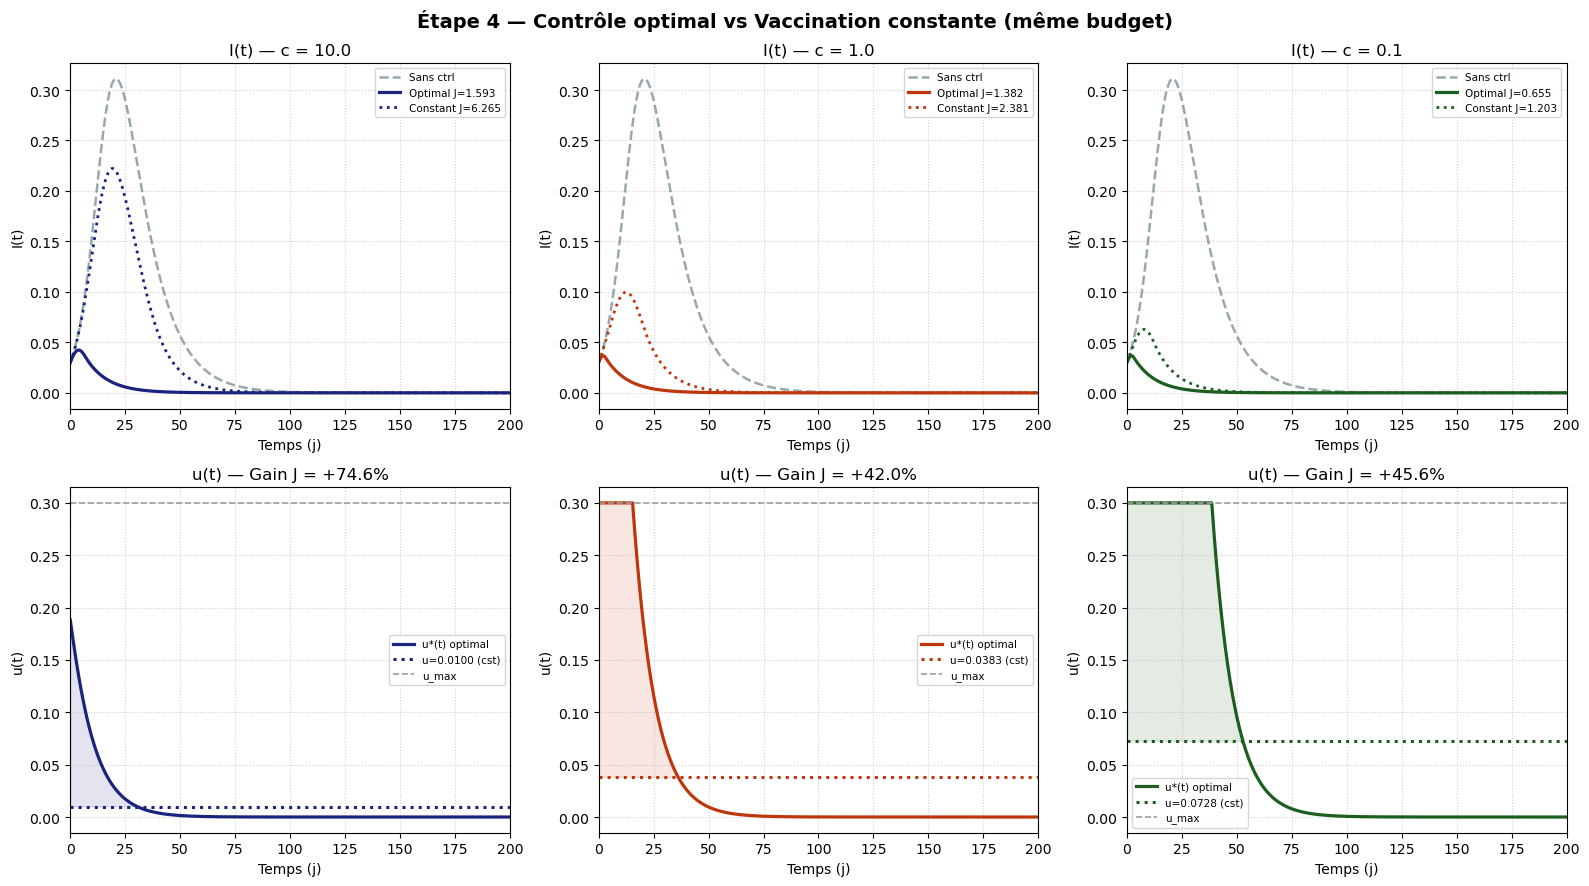

In [6]:
# ── Figure Étape 4 ──────────────────────────────────────────────────────────

plt.figure(figsize=(16, 9))
plt.suptitle('Étape 4 — Contrôle optimal vs Vaccination constante (même budget)',
             fontsize=14, fontweight='bold')

for idx, (c, ck) in enumerate(zip(c_vals, col_keys)):
    r  = RES[c]
    g  = gains[c]
    rc = g['rc']

    # --- Infectés I(t) ---
    # Positions 1, 2 et 3 selon l'itération
    plt.subplot(2, 3, idx + 1)
    
    plt.plot(t_arr, ref['I'], color=PAL['ref'], ls='--', alpha=0.6, lw=1.8, label='Sans ctrl')
    plt.plot(t_arr, r['I'],   color=PAL[ck], lw=2.3, label=f'Optimal J={r["J"]:.3f}')
    plt.plot(t_arr, rc['I'],  color=PAL[ck], lw=2.0, ls=':', label=f'Constant J={rc["J"]:.3f}')
    
    plt.title(f'I(t) — c = {c}')
    plt.xlabel('Temps (j)')
    plt.ylabel('I(t)')
    plt.xlim(0, T)
    plt.legend(fontsize=7.5)
    plt.grid(True, linestyle=':', alpha=0.6)

    # --- Contrôle u(t) ---
    # Positions 4, 5 et 6 selon l'itération
    plt.subplot(2, 3, idx + 4)
    
    plt.plot(t_arr, r['u'], color=PAL[ck], lw=2.3, label='u*(t) optimal')
    plt.axhline(y=g['uc'], color=PAL[ck], ls=':', lw=2.2, label=f'u={g["uc"]:.4f} (cst)')
    plt.axhline(y=UMAX, color='#9E9E9E', ls='--', lw=1.2, label='u_max')
    
    plt.fill_between(t_arr, r['u'], g['uc'], where=(r['u'] > g['uc']),
                     alpha=0.12, color=PAL[ck])
    
    plt.title(f'u(t) — Gain J = {g["gain"]:+.1f}%')
    plt.xlabel('Temps (j)')
    plt.ylabel('u(t)')
    plt.xlim(0, T)
    plt.legend(fontsize=7.5)
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.92) 

# Sauvegarde et affichage
plt.savefig('fig_etape4.png', dpi=150, bbox_inches='tight')
plt.show()



### Conclusion
- Le contrôle optimal concentre la vaccination en début d'épidémie, là où l'impact sur la chaîne de transmission est maximal.
- La vaccination constante gaspille une partie du budget en fin d'épidémie, quand S est déjà faible.

## 6. Étape 5 — Contrainte d'état I(t) ≤ I_max (méthode de pénalité) <a id='6'></a>

On ajoute un terme de pénalité au coût :
$$J_{\text{pén}} = \int_0^T \left[ I + \frac{c}{2}u^2 + \rho\,\max(0, I - I_{\max})^2 \right] dt$$

Ce qui modifie l'équation adjointe en :
$$\dot{\lambda}_I = -1 - 2\rho\,\max(0, I - I_{\max}) + \beta S(\lambda_S - \lambda_I) + \gamma\lambda_I$$


In [7]:
# ── Paramètres contrainte ────────────────────────────────────────────────────
I_MAX = 0.025   # seuil hospitalier (2.5% de la population)
RHO   = 800.0   # coefficient de pénalité
C    = 10.0    # valeur de c pour cette démonstration

r_nc  = RES[C]    # sans contrainte (déjà calculé)
print(f"Résolution avec contrainte I(t) ≤ {I_MAX} ...", end=" ")
r_pen = fb_sweep(C, I_max=I_MAX, rho=RHO, tol=1e-8, max_iter=8000)
print(f"J = {r_pen['J']:.4f}  ({r_pen['iters']} itérations)")

max_I_nc  = np.max(r_nc['I'])
max_I_pen = np.max(r_pen['I'])
viol_nc   = np.sum(r_nc['I']  > I_MAX) * DT
viol_pen  = np.sum(r_pen['I'] > I_MAX) * DT

print(f"\n  Sans contrainte : max(I)={max_I_nc:.4f}  dépassement={viol_nc:.1f} j")
print(f"  Avec pénalité   : max(I)={max_I_pen:.4f}  dépassement={viol_pen:.1f} j")
print(f"  Réduction max(I) : {100*(max_I_nc-max_I_pen)/max_I_nc:.1f}%")


Résolution avec contrainte I(t) ≤ 0.025 ... J = 1.8107  (32 itérations)

  Sans contrainte : max(I)=0.0424  dépassement=10.4 j
  Avec pénalité   : max(I)=0.0369  dépassement=7.2 j
  Réduction max(I) : 12.8%


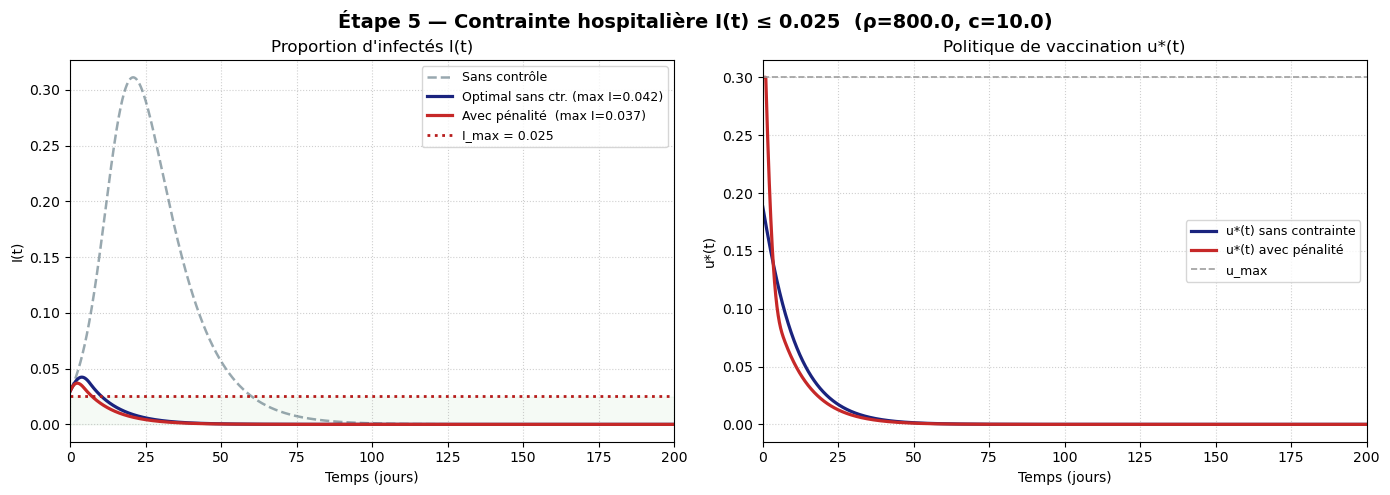

In [8]:
# ── Figure Étape 5 ──────────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.suptitle(f'Étape 5 — Contrainte hospitalière I(t) ≤ {I_MAX}  (ρ={RHO}, c={C})',
             fontsize=14, fontweight='bold')

# --- I(t) ---
plt.subplot(1, 2, 1)
plt.plot(t_arr, ref['I'],    color=PAL['ref'], ls='--', alpha=0.6, lw=1.8, label='Sans contrôle')
plt.plot(t_arr, r_nc['I'],   color=PAL['c10'], lw=2.3, label=f'Optimal sans ctr. (max I={max_I_nc:.3f})')
plt.plot(t_arr, r_pen['I'],  color=PAL['pen'], lw=2.3, label=f'Avec pénalité  (max I={max_I_pen:.3f})')

# Ligne de la contrainte hospitalière
plt.axhline(y=I_MAX, color='#B71C1C', ls=':', lw=2, label=f'I_max = {I_MAX}')

# Zone verte pour illustrer la zone de sécurité hospitalière
plt.fill_between(t_arr, 0, I_MAX, alpha=0.05, color='#43A047')

plt.title("Proportion d'infectés I(t)")
plt.xlabel('Temps (jours)')
plt.ylabel('I(t)')
plt.xlim(0, T)
plt.legend(fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6) 

# --- u(t) ---
plt.subplot(1, 2, 2) 
plt.plot(t_arr, r_nc['u'],  color=PAL['c10'], lw=2.3, label='u*(t) sans contrainte')
plt.plot(t_arr, r_pen['u'], color=PAL['pen'], lw=2.3, label='u*(t) avec pénalité')

# Ligne de la limite de vaccination quotidienne
plt.axhline(y=UMAX, color='#9E9E9E', ls='--', lw=1.2, label='u_max')

plt.title('Politique de vaccination u*(t)')
plt.xlabel('Temps (jours)')
plt.ylabel('u*(t)')
plt.xlim(0, T)
plt.legend(fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)

# --- Ajustements finaux et affichage ---
plt.tight_layout()
plt.subplots_adjust(top=0.88) 
plt.savefig('fig_etape5.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Synthèse et interprétation <a id='7'></a>

### 7.1 Tableau récapitulatif
### Analyse des performances du contrôle optimal

| Cas étudié | Valeur de la fonction coût optimale (J) | Taux de réduction par rapport à la référence | Gain d'efficacité par rapport à la vaccination constante | Type de contrôle identifié |
| :--- | :---: | :---: | :---: | :--- |
| **Référence sans contrôle** | ~9,43 | — | — | Aucun |
| **Coût c = 10** | ~1,59 | ~83% | ~+75% | Contrôle singulier (doux et progressif) |
| **Coût c = 1** | ~1,38 | ~85% | ~+42% | Contrôle mixte (saturé puis singulier) |
| **Coût c = 0,1** | ~0,65 | ~93% | ~+46% | Contrôle bang-bang (saturation initiale maximale) |

### 7.2 Interprétation du type de contrôle

**1. Contrôle singulier (intérieur)** pour $c$ grand :  
Le coût quadratique $cu^2/2$ lisse la solution. On obtient $u^*(t) = \lambda_S(t)/c$, une fonction continue décroissante — le contrôle est dit **singulier** ou **doux**.

**2. Saturation bang-bang** pour $c$ petit :  
Quand $c = 0.1$, la variable adjointe $\lambda_S$ dépasse $c \cdot u_{\max}$ sur une période initiale → $u^* = u_{\max}$ (saturation, contrôle **bang-bang**). Le contrôleur vaccine au maximum tant que les susceptibles sont nombreux.

**3. Temporalité optimale** :  
Le contrôle optimal concentre la vaccination **en début d'épidémie**, là où chaque personne vaccinée coupe le plus grand nombre de chaînes de transmission. La vaccination constante "gaspille" une partie du budget en fin d'épidémie, quand $S$ est déjà faible.

**4. Condition de transversalité** :  
$\lambda_S(T) = 0$ est bien vérifiée numériquement → l'algorithme converge vers la solution optimale de Pontryagin.
